# Proceso Analítico Jerárquico (AHP)
## Ponderación de factores de riesgo y protección para el reclutamiento adolescente por el crimen organizado

**Tesina — Licenciatura en Matemáticas Aplicadas, ITAM**  
**Autora:** María Alejandra Galicia Almaraz  
**Directora:** Dra. Mayra Núñez  

---

Este notebook implementa el Proceso Analítico Jerárquico (AHP) desarrollado en el Capítulo 3 de la tesina. El objetivo es derivar vectores de pesos para los **siete factores de riesgo** (F1–F7) y los **tres factores de protección** (P1–P3) a partir de las matrices de comparación por pares proporcionadas por los expertos del tema.

El análisis incluye:
1. Ingreso y validación de matrices por experto
2. Estimación del vector de pesos por dos métodos: columna normalizada y vector propio (potencias)
3. Cálculo del índice de consistencia (IC) y ratio de consistencia (RC)
4. Agregación grupal de los vectores individuales mediante media geométrica y media aritmética
5. Comparación de ambas formas de agregación
6. Visualizaciones de los resultados

---
## Sección 0: Importación de librerías

En esta sección se importan todas las librerías necesarias para el análisis. Se utiliza `numpy` para el álgebra lineal (operaciones matriciales, cálculo de eigenvalores y eigenvectores), `pandas` para organizar y presentar los resultados en tablas legibles, y `matplotlib` junto con `seaborn` para las visualizaciones.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.stats import gmean  # para media geométrica
import warnings
warnings.filterwarnings('ignore')

# Configuración general de visualización
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'serif'
sns.set_style('whitegrid')

print('Librerías cargadas correctamente.')

Librerías cargadas correctamente.


---
## Sección 1: Definición de los factores y la escala de Saaty

Antes de ingresar cualquier dato, se definen los nombres de los factores tal como aparecen en el Capítulo 2 de la tesina. Esta nomenclatura se usará de manera consistente en todas las tablas y gráficas del análisis.

También se muestra la **escala fundamental de Saaty (1977)** que los expertos utilizaron para emitir sus juicios comparativos. Los valores van del 1 al 9, donde 1 significa igual importancia y 9 significa importancia extremadamente mayor de un factor sobre el otro. Los valores recíprocos (1/2, 1/3, ..., 1/9) se usan cuando el factor de la fila es menos importante que el de la columna.

In [2]:
# ─────────────────────────────────────────────────────────────
# Nombres de los factores de riesgo (F1 a F7)
# ─────────────────────────────────────────────────────────────
FACTORES_RIESGO = [
    'F1: Violencia en el entorno',
    'F2: Precariedad económica familiar',
    'F3: Deserción escolar',
    'F4: Identificación con narcocultura',
    'F5: Proximidad al crimen organizado',
    'F6: Uso de sustancias',
    'F7: Ausencia de pertenencia prosocial'
]

# Etiquetas cortas para gráficas
ETIQUETAS_RIESGO = ['F1', 'F2', 'F3', 'F4', 'F5', 'F6', 'F7']

# ─────────────────────────────────────────────────────────────
# Nombres de los factores de protección (P1 a P3)
# ─────────────────────────────────────────────────────────────
FACTORES_PROTECCION = [
    'P1: Red de apoyo adulto activa',
    'P2: Expectativas de futuro',
    'P3: Participación en actividad estructurada'
]

ETIQUETAS_PROTECCION = ['P1', 'P2', 'P3']

# ─────────────────────────────────────────────────────────────
# Escala fundamental de Saaty (1977) — solo para referencia
# ─────────────────────────────────────────────────────────────
escala_saaty = pd.DataFrame({
    'Valor': [1, 2, 3, 4, 5, 6, 7, 8, 9],
    'Interpretación': [
        'Igual importancia',
        'Entre igual y moderada',
        'Moderadamente más importante',
        'Entre moderada y fuerte',
        'Fuertemente más importante',
        'Entre fuerte y muy fuerte',
        'Muy fuertemente más importante',
        'Entre muy fuerte y extrema',
        'Extremadamente más importante'
    ]
})

print('Escala fundamental de Saaty (1977):')
print(escala_saaty.to_string(index=False))
print()
print(f'Factores de riesgo definidos: {len(FACTORES_RIESGO)}')
print(f'Factores de protección definidos: {len(FACTORES_PROTECCION)}')

Escala fundamental de Saaty (1977):
 Valor                 Interpretación
     1              Igual importancia
     2         Entre igual y moderada
     3   Moderadamente más importante
     4        Entre moderada y fuerte
     5     Fuertemente más importante
     6      Entre fuerte y muy fuerte
     7 Muy fuertemente más importante
     8     Entre muy fuerte y extrema
     9  Extremadamente más importante

Factores de riesgo definidos: 7
Factores de protección definidos: 3


---
## Sección 2: Índice de consistencia aleatorio IA(n)

El ratio de consistencia (RC) que se calculará más adelante requiere dividir el índice de consistencia (IC) entre el índice de consistencia aleatorio IA(n), que representa el nivel de inconsistencia esperado cuando los juicios se emiten de manera completamente aleatoria. Estos valores fueron tabulados por Saaty (1977) mediante simulaciones.

Se definen aquí como una constante global porque son los mismos para cualquier análisis AHP con matrices de ese tamaño. Para esta tesina los valores relevantes son IA(7) = 1.32 (factores de riesgo) e IA(3) = 0.58 (factores de protección).

In [3]:
# Índice de consistencia aleatorio IA(n) tabulado por Saaty (1977)
# Las llaves son el número de criterios n; los valores son IA(n)
IA = {
    1: 0.00,
    2: 0.00,
    3: 0.58,
    4: 0.90,
    5: 1.12,
    6: 1.24,
    7: 1.32,
    8: 1.41,
    9: 1.45,
    10: 1.49
}

# Mostrar la tabla para verificación
df_ia = pd.DataFrame(list(IA.items()), columns=['n (número de criterios)', 'IA(n)'])
print('Índice de consistencia aleatorio IA(n) — Saaty (1977):')
print(df_ia.to_string(index=False))
print()
print(f'IA relevante para factores de riesgo  (n=7): {IA[7]}')
print(f'IA relevante para factores de protección (n=3): {IA[3]}')

Índice de consistencia aleatorio IA(n) — Saaty (1977):
 n (número de criterios)  IA(n)
                       1   0.00
                       2   0.00
                       3   0.58
                       4   0.90
                       5   1.12
                       6   1.24
                       7   1.32
                       8   1.41
                       9   1.45
                      10   1.49

IA relevante para factores de riesgo  (n=7): 1.32
IA relevante para factores de protección (n=3): 0.58


---
## Sección 3: Funciones del método AHP

En esta sección se implementan todas las funciones matemáticas del método AHP. Cada función corresponde a un paso del procedimiento descrito en el Capítulo 3 de la tesina. Al separar el código en funciones reutilizables, el mismo procedimiento puede aplicarse tanto a las matrices de factores de riesgo como a las de protección, y tanto a matrices individuales como a la agregación grupal.

Las funciones implementadas son:

- **`validar_matriz(A)`**: verifica que la matriz sea positiva, tenga diagonal unitaria y sea recíproca.
- **`metodo_columna_normalizada(A)`**: estima el vector de pesos mediante el promedio de columnas normalizadas.
- **`metodo_potencias(A, tol, max_iter)`**: estima el vector de pesos mediante iteración de potencias, convergiendo al eigenvector principal exacto.
- **`calcular_lambda_max(A, w)`**: calcula el eigenvalor dominante λ_max a partir del vector de pesos estimado.
- **`calcular_consistencia(A, w)`**: calcula IC y RC a partir de λ_max.
- **`analizar_matriz(A, etiquetas, nombre)`**: función principal que integra todos los pasos anteriores y devuelve un reporte completo.

In [4]:
# ═══════════════════════════════════════════════════════════════════
# FUNCIÓN 1: Validación de la matriz de comparación por pares
# ═══════════════════════════════════════════════════════════════════
def validar_matriz(A, nombre='Matriz'):
    """
    Verifica que la matriz A cumpla las tres propiedades estructurales
    del AHP definidas en el Capítulo 3 de la tesina:
      1. Positividad:      aij > 0 para todo i, j
      2. Diagonal unitaria: aii = 1 para todo i
      3. Reciprocidad:     aji = 1/aij para todo i ≠ j

    Parámetros
    ----------
    A      : np.ndarray — matriz cuadrada de comparación por pares
    nombre : str        — nombre descriptivo para los mensajes de salida

    Retorna
    -------
    bool — True si la matriz es válida, False en caso contrario
    """
    n = A.shape[0]
    errores = []

    # Propiedad 1: Positividad
    if not np.all(A > 0):
        errores.append('La matriz contiene entradas no positivas (aij ≤ 0).')

    # Propiedad 2: Diagonal unitaria
    if not np.allclose(np.diag(A), 1.0):
        errores.append('La diagonal no es completamente unitaria (aii ≠ 1).')

    # Propiedad 3: Reciprocidad (aji ≈ 1/aij)
    for i in range(n):
        for j in range(i+1, n):
            if not np.isclose(A[j, i], 1.0 / A[i, j], rtol=1e-4):
                errores.append(
                    f'  Reciprocidad violada en ({i+1},{j+1}): '
                    f'a[{i+1},{j+1}]={A[i,j]:.4f}, '
                    f'a[{j+1},{i+1}]={A[j,i]:.4f} '
                    f'(se esperaba {1/A[i,j]:.4f})'
                )

    if errores:
        print(f'[{nombre}] ✗ La matriz NO pasa la validación:')
        for e in errores:
            print(f'   {e}')
        return False
    else:
        print(f'[{nombre}] ✓ La matriz es válida (positiva, diagonal=1, recíproca).')
        return True


# ═══════════════════════════════════════════════════════════════════
# FUNCIÓN 2: Método de la columna normalizada
# ═══════════════════════════════════════════════════════════════════
def metodo_columna_normalizada(A):
    """
    Estima el vector de pesos w mediante el método de la columna
    normalizada, descrito en la Sección 3.4.1 de la tesina.

    Procedimiento:
      Paso 1 — Normalizar cada columna j: ā_ij = a_ij / Σ_k a_kj
      Paso 2 — Estimar el peso del factor i: ŵ_i = (1/n) * Σ_j ā_ij

    En el caso perfectamente consistente, cada columna normalizada
    reproduce exactamente el vector de pesos verdadero. En el caso
    real, el promedio de las n columnas normalizadas da una estimación
    más robusta que cualquier columna individual.

    Parámetros
    ----------
    A : np.ndarray — matriz de comparación por pares (n×n)

    Retorna
    -------
    w_hat : np.ndarray — vector de pesos estimado, suma = 1
    """
    n = A.shape[0]

    # Paso 1: Normalizar por columna
    col_sums = A.sum(axis=0)           # suma de cada columna
    A_norm = A / col_sums              # división elemento a elemento

    # Paso 2: Promedio de cada fila de la matriz normalizada
    w_hat = A_norm.mean(axis=1)        # promedio a lo largo de las columnas

    # Verificación: los pesos deben sumar 1
    assert np.isclose(w_hat.sum(), 1.0, atol=1e-8), 'Error: los pesos no suman 1.'

    return w_hat


# ═══════════════════════════════════════════════════════════════════
# FUNCIÓN 3: Método del vector propio (potencias)
# ═══════════════════════════════════════════════════════════════════
def metodo_potencias(A, tol=1e-10, max_iter=1000):
    """
    Estima el vector de pesos w mediante el método de potencias,
    descrito en la Sección 3.4.2 de la tesina.

    El método construye la sucesión:
        v^(k) = A * v^(k-1) / ||A * v^(k-1)||_1

    que, por el Teorema de Perron-Frobenius, converge al eigenvector
    principal normalizado de A (asociado a λ_max). La velocidad de
    convergencia depende de la razón |λ_2|/λ_max.

    Parámetros
    ----------
    A        : np.ndarray — matriz de comparación por pares (n×n)
    tol      : float      — tolerancia de convergencia (norma L1 entre iteraciones)
    max_iter : int        — número máximo de iteraciones

    Retorna
    -------
    w_hat    : np.ndarray — vector de pesos estimado, suma = 1
    num_iter : int        — número de iteraciones hasta convergencia
    """
    n = A.shape[0]

    # Vector inicial: uniforme (todos los factores igualmente importantes)
    # Cualquier vector positivo no ortogonal al eigenespacio de λ_max funciona.
    v = np.ones(n) / n

    for k in range(1, max_iter + 1):
        # Multiplicación por A
        v_new = A @ v

        # Normalización por norma L1 para que las componentes sumen 1
        v_new = v_new / v_new.sum()

        # Criterio de convergencia: cambio máximo entre iteraciones
        if np.linalg.norm(v_new - v, 1) < tol:
            return v_new, k

        v = v_new

    # Si no convergió dentro de max_iter iteraciones, se advierte pero
    # se devuelve la mejor aproximación disponible
    print(f'  Advertencia: el método de potencias no convergió en {max_iter} iteraciones.')
    return v, max_iter


# ═══════════════════════════════════════════════════════════════════
# FUNCIÓN 4: Cálculo de λ_max
# ═══════════════════════════════════════════════════════════════════
def calcular_lambda_max(A, w):
    """
    Calcula el eigenvalor dominante λ_max a partir del vector de pesos
    estimado w, usando la fórmula derivada en la Sección 3.4.2:

        λ_max = (1/n) * Σ_i [(A @ w)_i / w_i]

    Esta expresión se obtiene despejando λ_max de la ecuación de
    eigenvalor A @ w ≈ λ_max * w y promediando sobre todas las filas
    para reducir el error de estimación.

    Parámetros
    ----------
    A : np.ndarray — matriz de comparación por pares (n×n)
    w : np.ndarray — vector de pesos estimado

    Retorna
    -------
    lambda_max : float — eigenvalor dominante estimado
    """
    n = A.shape[0]
    Aw = A @ w                      # producto A * w
    ratios = Aw / w                 # cocientes (Aw)_i / w_i por fila
    lambda_max = ratios.mean()      # promedio sobre las n filas
    return lambda_max


# ═══════════════════════════════════════════════════════════════════
# FUNCIÓN 5: Índice y ratio de consistencia
# ═══════════════════════════════════════════════════════════════════
def calcular_consistencia(A, w):
    """
    Calcula el Índice de Consistencia (IC) y el Ratio de Consistencia
    (RC), definidos en las Secciones 3.5.1 y 3.5.2 de la tesina:

        IC = (λ_max - n) / (n - 1)
        RC = IC / IA(n)

    El criterio de aceptación de Saaty (1977) es RC < 0.10.
    Sin embargo, en el presente trabajo se considera que si RC ≥ 0.37, los juicios del experto deben revisarse.

    Parámetros
    ----------
    A : np.ndarray — matriz de comparación por pares (n×n)
    w : np.ndarray — vector de pesos estimado

    Retorna
    -------
    dict con: lambda_max, IC, IA, RC, consistente (bool)
    """
    n = A.shape[0]
    lambda_max = calcular_lambda_max(A, w)

    IC = (lambda_max - n) / (n - 1)

    ia = IA.get(n, None)
    if ia is None or ia == 0:
        # Para n=1 o n=2 no hay inconsistencia posible
        RC = 0.0
    else:
        RC = IC / ia

    return {
        'lambda_max': lambda_max,
        'n': n,
        'IC': IC,
        'IA': ia,
        'RC': RC,
        'consistente': RC < 0.37
    }


# ═══════════════════════════════════════════════════════════════════
# FUNCIÓN 6: Análisis completo de una matriz
# ═══════════════════════════════════════════════════════════════════
def analizar_matriz(A, etiquetas, nombre='Experto'):
    """
    Función principal que integra todos los pasos del AHP para una
    matriz individual. Aplica ambos métodos de estimación y calcula
    los índices de consistencia para cada uno.

    Parámetros
    ----------
    A         : np.ndarray — matriz de comparación por pares (n×n)
    etiquetas : list[str]  — nombres cortos de los factores (para tablas)
    nombre    : str        — identificador del experto o matriz

    Retorna
    -------
    dict con todos los resultados: pesos por ambos métodos,
    consistencia, número de iteraciones del método de potencias
    """
    n = A.shape[0]
    print(f'\n{"═"*60}')
    print(f'  Análisis AHP — {nombre}')
    print(f'{"═"*60}')

    # ── Validación ──────────────────────────────────────────────
    valida = validar_matriz(A, nombre)
    if not valida:
        print('  ⚠ Revisa la matriz antes de continuar.')
        return None

    # ── Método 1: Columna normalizada ───────────────────────────
    w_cn = metodo_columna_normalizada(A)
    cons_cn = calcular_consistencia(A, w_cn)

    # ── Método 2: Vector propio (potencias) ─────────────────────
    w_pot, n_iter = metodo_potencias(A)
    cons_pot = calcular_consistencia(A, w_pot)

    # ── Tabla comparativa de pesos ──────────────────────────────
    df_pesos = pd.DataFrame({
        'Factor': etiquetas,
        'Peso (Col. Norm.)': np.round(w_cn, 6),
        'Peso (Potencias)': np.round(w_pot, 6),
        'Diferencia abs.': np.round(np.abs(w_cn - w_pot), 8)
    })

    print(f'\n  Vectores de pesos estimados:')
    print(df_pesos.to_string(index=False))

    # ── Tabla de consistencia ────────────────────────────────────
    print(f'\n  Índices de consistencia:')
    print(f'  {"Método":<28} {"λ_max":>8} {"IC":>8} {"IA(n)":>8} {"RC":>8} {"RC<0.37":>10}')
    print(f'  {"-"*72}')

    for metodo, cons in [('Columna normalizada', cons_cn), ('Potencias (eigenvector)', cons_pot)]:
        estado = '✓ Sí' if cons['consistente'] else '✗ No — revisar'
        print(
            f'  {metodo:<28} '
            f'{cons["lambda_max"]:>8.4f} '
            f'{cons["IC"]:>8.4f} '
            f'{cons["IA"]:>8.2f} '
            f'{cons["RC"]:>8.4f} '
            f'{estado:>12}'
        )

    print(f'\n  Iteraciones (método de potencias): {n_iter}')

    return {
        'nombre': nombre,
        'A': A,
        'etiquetas': etiquetas,
        'w_columna_norm': w_cn,
        'w_potencias': w_pot,
        'consistencia_cn': cons_cn,
        'consistencia_pot': cons_pot,
        'n_iter': n_iter,
        'valida': valida
    }

print('Funciones AHP definidas correctamente.')

Funciones AHP definidas correctamente.


---
## Sección 4: Ingreso de matrices — Factores de Riesgo (7×7)

En esta sección se ingresan las matrices de comparación por pares para los **siete factores de riesgo** (F1–F7) proporcionadas por cada experto consultado.

### Cómo leer la matriz
La entrada `A[i, j]` representa cuánto **más importante** es el factor de la **fila i** respecto al factor de la **columna j** según el juicio del experto. Por ejemplo:
- `A[0, 1] = 3` significa que F1 es **moderadamente más importante** que F2.
- `A[1, 0]` debe ser automáticamente `1/3` (reciprocidad).
- La diagonal siempre es 1 (un factor comparado consigo mismo).

### Instrucciones de llenado
Solo necesitas ingresar la **triangular superior** (encima de la diagonal). La triangular inferior se construye usando los recíprocos:
```
A = np.array([
    [  1,  a12, a13, a14, a15, a16, a17],
    [1/a12,  1, a23, a24, a25, a26, a27],
    [1/a13, 1/a23, 1, a34, a35, a36, a37],
    ... y así sucesivamente
])
```


In [5]:

# ── Experto 1 — Factores de Riesgo ──────────────────────────────────────────
A_riesgo_1 = np.array([
    #   F1      F2      F3      F4      F5      F6      F7
    [   1,    1/6,     6,      6,      4,      4,      4  ],  # F1
    [   6,      1,     6,      7,      6,      5,      4  ],  # F2
    [ 1/6,    1/6,     1,    1/4,    1/8,      4,      4  ],  # F3
    [ 1/6,    1/7,     4,      1,    1/7,      4,      4  ],  # F4
    [ 1/4,    1/6,     8,      7,      1,      3,      8  ],  # F5
    [ 1/4,    1/5,   1/4,    1/4,    1/3,      1,      1  ],  # F6
    [ 1/4,    1/4,   1/4,    1/4,    1/8,      1,      1  ],  # F7
])

# Experto 2 — Factores de Riesgo 
A_riesgo_2 = np.array([
    #   F1      F2      F3      F4      F5      F6      F7
    [   1,      6,    1/3,    1/6,    1/4,      3,    1/7  ],  # F1
    [ 1/6,      1,    1/6,    1/7,      7,    1/4,    1/7  ],  # F2
    [   3,      6,      1,      1,    1/7,    1/3,    1/7  ],  # F3
    [   6,      7,      1,      1,      6,      6,      7  ],  # F4
    [   4,    1/7,      7,    1/6,      1,      7,      6  ],  # F5
    [ 1/3,      4,      3,    1/6,    1/7,      1,    1/7  ],  # F6
    [   7,      7,      7,    1/7,    1/6,      7,      1  ],  # F7
])

#Experto 3 — Factores de Riesgo 

A_riesgo_3 = np.array([
    #   F1     F2     F3     F4     F5     F6     F7
    [   1,      7,      3,      8,      1,      1,    1/4 ],  # F1
    [ 1/7,      1,    1/4,    1/6,    1/8,    1/6,    1/8 ],  # F2
    [ 1/3,      4,      1,      1,    1/6,    1/5,      1 ],  # F3
    [ 1/8,      6,      1,      1,    1/4,    1/4,    1/3 ],  # F4
    [   1,      8,      6,      4,      1,      4,      2 ],  # F5
    [   1,      6,      5,      4,    1/4,      1,      1 ],  # F6
    [   4,      8,      1,      3,    1/2,      1,      1 ]   # F7
])



#Experto 4 — Factores de Riesgo 
A_riesgo_4 = np.array([
    #   F1     F2     F3     F4     F5     F6     F7
    [   1,      4,      3,      6,    1/5,    1/7,      6 ],  # F1
    [ 1/4,      1,      3,      7,      1,      7,      7 ],  # F2
    [ 1/3,    1/3,      1,      8,    1/8,      1,      5 ],  # F3
    [ 1/6,    1/7,    1/8,      1,    1/8,    1/7,    1/5 ],  # F4
    [   5,      1,      8,      8,      1,      1,      8 ],  # F5
    [   7,    1/7,      1,      7,      1,      1,      7 ],  # F6
    [ 1/6,    1/7,    1/5,      5,    1/8,    1/7,      1 ]   # F7
])




#Experto 5 — Factores de Riesgo 
A_riesgo_5 = np.array([
    #   F1     F2     F3     F4     F5     F6     F7
    [   1,      9,      1,      9,    1/9,      1,      2 ],  # F1
    [ 1/9,      1,    1/9,    1/2,    1/9,    1/9,    1/9 ],  # F2
    [   1,      9,      1,      9,    1/9,    1/2,      8 ],  # F3
    [ 1/9,      2,    1/9,      1,    1/9,    1/9,    1/9 ],  # F4
    [   9,      9,      9,      9,      1,      9,      9 ],  # F5
    [   1,      9,      2,      9,    1/9,      1,      2 ],  # F6
    [ 1/2,      9,    1/8,      9,    1/9,    1/2,      1 ]   # F7
])

# ── Lista de todas las matrices de riesgo con su etiqueta ───────────────────
matrices_riesgo = [
    (A_riesgo_1, 'Experto 1 — Riesgo'),
    (A_riesgo_2, 'Experto 2 — Riesgo'),
    (A_riesgo_3, 'Experto 3 — Riesgo'),
    (A_riesgo_4, 'Experto 4 — Riesgo'),
    (A_riesgo_5, 'Experto 5 — Riesgo'),
]

print(f'Matrices de factores de riesgo registradas: {len(matrices_riesgo)}')

Matrices de factores de riesgo registradas: 5


---
## Sección 5: Ingreso de matrices — Factores de Protección (3×3)

Aquí se ingresan las matrices de comparación por pares para los **tres factores de protección** (P1–P3). Al ser matrices 3×3, solo se requieren **3 comparaciones independientes** por experto (la triangular superior, sin incluir la diagonal).

El orden de los factores en filas y columnas es siempre: **P1, P2, P3**.

In [6]:
# ── Experto 1 — Factores de Protección ──────────────────────────────────────
A_protectora_1 = np.array([
    #   F1      F2      F3
    [   1,      6,      6  ],  # F1
    [ 1/6,      1,      6  ],  # F2
    [ 1/6,    1/6,      1  ],  # F3
])

#  Experto 2 — Factores de Protección 
A_protectora_2 = np.array([
    #   F1      F2      F3
    [   1,      6,    1/7  ],  # F1
    [ 1/6,      1,    1/7  ],  # F2
    [   7,      7,      1  ],  # F3
])

#  Experto 3— Factores de Protección 
A_protectora_3 = np.array([
    #   F1     F2     F3
    [   1,      4,      1 ],  # F1
    [ 1/4,      1,      1 ],  # F2
    [   1,      1,      1 ]   # F3
])

#  Experto 4— Factores de Protección 
A_protectora_4= np.array([
    #   F1     F2     F3
    [   1,      7,      1 ],  # F1
    [ 1/7,      1,    1/3 ],  # F2
    [   1,      3,      1 ]   # F3
])


#  Experto 5— Factores de Protección 

A_protectora_5 = np.array([
    #   F1     F2     F3
    [   1,      5,      5 ],  # F1
    [ 1/5,      1,    1/2 ],  # F2
    [ 1/5,      2,      1 ]   # F3
])

# ── Lista de todas las matrices de protección ────────────────────────────────
matrices_proteccion = [
    (A_protectora_1, 'Experto 1 — Protección'),
    (A_protectora_2, 'Experto 2 — Protección'),
    (A_protectora_3, 'Experto 3 — Protección'),
    (A_protectora_4, 'Experto 4 — Protección'),
    (A_protectora_5, 'Experto 5 — Protección'),
]

print(f'Matrices de factores de protección registradas: {len(matrices_proteccion)}')

Matrices de factores de protección registradas: 5


---
## Sección 6: Análisis individual por experto — Factores de Riesgo

En esta sección se aplica el análisis AHP completo a cada una de las matrices de factores de riesgo de manera individual. Para cada experto se ejecutan los dos métodos de estimación del vector de pesos y se reportan los índices de consistencia.

Los resultados de cada experto se almacenan en la lista `resultados_riesgo` para ser utilizados posteriormente en la agregación grupal.

In [7]:
# Aplicar el análisis a cada matriz de factores de riesgo
resultados_riesgo = []

for A, nombre in matrices_riesgo:
    resultado = analizar_matriz(A, ETIQUETAS_RIESGO, nombre)
    if resultado is not None:
        resultados_riesgo.append(resultado)

print(f'\nMatrices de riesgo analizadas exitosamente: {len(resultados_riesgo)} de {len(matrices_riesgo)}')


════════════════════════════════════════════════════════════
  Análisis AHP — Experto 1 — Riesgo
════════════════════════════════════════════════════════════
[Experto 1 — Riesgo] ✓ La matriz es válida (positiva, diagonal=1, recíproca).

  Vectores de pesos estimados:
Factor  Peso (Col. Norm.)  Peso (Potencias)  Diferencia abs.
    F1           0.198755          0.217235         0.018480
    F2           0.381430          0.427209         0.045779
    F3           0.071041          0.049843         0.021198
    F4           0.091366          0.071654         0.019712
    F5           0.182209          0.171136         0.011073
    F6           0.037162          0.032257         0.004905
    F7           0.038037          0.030667         0.007369

  Índices de consistencia:
  Método                          λ_max       IC    IA(n)       RC    RC<0.37
  ------------------------------------------------------------------------
  Columna normalizada            9.1556   0.3593     1.32   0.

---
## Sección 7: Análisis individual por experto — Factores de Protección

Se repite el mismo procedimiento para las matrices de factores de protección (3×3). Al ser matrices más pequeñas, la consistencia es más fácil de mantener: con solo 3 comparaciones independientes, las posibilidades de contradicción interna son mínimas. Sin embargo, el código verifica el RC igualmente para completitud.

In [8]:
# Aplicar el análisis a cada matriz de factores de protección
resultados_proteccion = []

for A, nombre in matrices_proteccion:
    resultado = analizar_matriz(A, ETIQUETAS_PROTECCION, nombre)
    if resultado is not None:
        resultados_proteccion.append(resultado)

print(f'\nMatrices de protección analizadas exitosamente: {len(resultados_proteccion)} de {len(matrices_proteccion)}')


════════════════════════════════════════════════════════════
  Análisis AHP — Experto 1 — Protección
════════════════════════════════════════════════════════════
[Experto 1 — Protección] ✓ La matriz es válida (positiva, diagonal=1, recíproca).

  Vectores de pesos estimados:
Factor  Peso (Col. Norm.)  Peso (Potencias)  Diferencia abs.
    P1           0.682916          0.717065         0.034149
    P2           0.242024          0.217166         0.024859
    P3           0.075060          0.065769         0.009290

  Índices de consistencia:
  Método                          λ_max       IC    IA(n)       RC    RC<0.37
  ------------------------------------------------------------------------
  Columna normalizada            3.3902   0.1951     0.58   0.3364         ✓ Sí
  Potencias (eigenvector)        3.3674   0.1837     0.58   0.3168         ✓ Sí

  Iteraciones (método de potencias): 21

════════════════════════════════════════════════════════════
  Análisis AHP — Experto 2 — Protec

---
## Sección 8: Resumen de consistencia — todos los expertos

Antes de proceder a la agregación grupal, es necesario verificar que **todas** las matrices individuales cumplen el criterio RC < 0.37. En la tesina se establece que solo las matrices que satisfagan este umbral serán consideradas en la derivación del vector de pesos grupal. Si alguna no lo cumple, el experto correspondiente deberá revisar y corregir sus comparaciones.

Esta celda genera un resumen global que permite identificar de un vistazo qué matrices son aptas para la agregación.

In [9]:
def tabla_resumen_consistencia(resultados, tipo='Riesgo'):
    """
    Genera una tabla resumen con los índices de consistencia
    de todos los expertos para un tipo de matriz dado.
    Usa el método de potencias (más preciso) como referencia.
    """
    filas = []
    for r in resultados:
        c = r['consistencia_pot']  # se usa el método de potencias como referencia
        filas.append({
            'Experto': r['nombre'],
            'n': c['n'],
            'λ_max': round(c['lambda_max'], 4),
            'IC': round(c['IC'], 4),
            'IA(n)': c['IA'],
            'RC': round(c['RC'], 4),
            'Aceptable (RC<0.37)': '✓ Sí' if c['consistente'] else '✗ No — revisar'
        })

    df = pd.DataFrame(filas)
    print(f'\nResumen de consistencia — Factores de {tipo} (método de potencias):')
    print(df.to_string(index=False))

    n_aptas = sum(1 for r in resultados if r['consistencia_pot']['consistente'])
    print(f'\nMatrices aptas para agregación: {n_aptas} de {len(resultados)}')

    return df

# Resúmenes de consistencia
df_cons_riesgo = tabla_resumen_consistencia(resultados_riesgo, tipo='Riesgo')
df_cons_prot   = tabla_resumen_consistencia(resultados_proteccion, tipo='Protección')


Resumen de consistencia — Factores de Riesgo (método de potencias):
           Experto  n   λ_max     IC  IA(n)     RC Aceptable (RC<0.37)
Experto 1 — Riesgo  7  8.9933 0.3322   1.32 0.2517                ✓ Sí
Experto 2 — Riesgo  7 14.3913 1.2319   1.32 0.9333      ✗ No — revisar
Experto 3 — Riesgo  7  8.0455 0.1743   1.32 0.1320                ✓ Sí
Experto 4 — Riesgo  7  9.8945 0.4824   1.32 0.3655                ✓ Sí
Experto 5 — Riesgo  7  8.5166 0.2528   1.32 0.1915                ✓ Sí

Matrices aptas para agregación: 4 de 5

Resumen de consistencia — Factores de Protección (método de potencias):
               Experto  n  λ_max     IC  IA(n)     RC Aceptable (RC<0.37)
Experto 1 — Protección  3 3.3674 0.1837   0.58 0.3168                ✓ Sí
Experto 2 — Protección  3 3.3674 0.1837   0.58 0.3168                ✓ Sí
Experto 3 — Protección  3 3.2174 0.1087   0.58 0.1874                ✓ Sí
Experto 4 — Protección  3 3.0803 0.0401   0.58 0.0692                ✓ Sí
Experto 5 — Protección

---
## Sección 9: Agregación grupal de los vectores de pesos

Una vez verificada la consistencia individual, se procede a derivar un **único vector de pesos grupal** que sintetice los juicios de todos los expertos. Se implementan y comparan dos métodos de agregación:

### Método A: Media geométrica de los pesos individuales (AIJ — Aggregation of Individual Judgments)
Para cada factor $i$, el peso grupal se calcula como la media geométrica de los pesos individuales de los $m$ expertos:
$$\bar{w}_i^{\text{geom}} = \left(\prod_{k=1}^{m} \hat{w}_i^{(k)}\right)^{1/m}$$
El vector resultante se normaliza para que sus componentes sumen 1. Este método es el estándar en la literatura de AHP grupal porque preserva la propiedad de reciprocidad y es consistente con la estructura multiplicativa de la escala de Saaty.

### Método B: Media aritmética de los pesos individuales
Para cada factor $i$, el peso grupal es el promedio aritmético:
$$\bar{w}_i^{\text{arit}} = \frac{1}{m}\sum_{k=1}^{m} \hat{w}_i^{(k)}$$
Este método es más intuitivo pero puede sobrestimar el peso de expertos con valores extremos y no preserva la reciprocidad en la escala original.

En ambos casos se usan los vectores de pesos derivados por el **método de potencias** como insumo, por ser el método de estimación más preciso.

In [10]:
def agregar_pesos(resultados, etiquetas, tipo='Riesgo'):
    """
    Agrega los vectores de pesos individuales (método de potencias)
    de todos los expertos que pasaron el criterio RC < 0.37,
    usando media geométrica y media aritmética.

    Parámetros
    ----------
    resultados : list  — salida de analizar_matriz para cada experto
    etiquetas  : list  — nombres cortos de los factores
    tipo       : str   — 'Riesgo' o 'Protección'

    Retorna
    -------
    dict con los vectores agregados y la tabla comparativa
    """
    # Filtrar solo los expertos con matrices aceptables
    aptos = [r for r in resultados if r['consistencia_pot']['consistente']]

    if len(aptos) == 0:
        print('⚠ No hay matrices con RC < 0.37. No es posible agregar.')
        return None

    print(f'\n{"═"*60}')
    print(f'  Agregación grupal — Factores de {tipo}')
    print(f'  Expertos incluidos: {len(aptos)} de {len(resultados)}')
    print(f'{"═"*60}')

    # Matriz donde cada fila es el vector de pesos de un experto
    W = np.array([r['w_potencias'] for r in aptos])  # forma: (m × n)
    m, n = W.shape

    # ── Método A: Media geométrica ───────────────────────────────
    # gmean opera sobre columnas (axis=0) → da la media geométrica
    # de los pesos de cada factor a través de los m expertos
    w_geom_raw = gmean(W, axis=0)
    w_geom = w_geom_raw / w_geom_raw.sum()  # normalizar

    # ── Método B: Media aritmética ───────────────────────────────
    w_arit = W.mean(axis=0)  # promedio por columna; ya suma 1 si cada fila suma 1
    w_arit = w_arit / w_arit.sum()  # normalizar por si hay error de redondeo

    # ── Tabla comparativa ────────────────────────────────────────
    df = pd.DataFrame({'Factor': etiquetas})

    for i, r in enumerate(aptos):
        nombre_corto = r['nombre'].split('—')[0].strip()
        df[nombre_corto] = np.round(r['w_potencias'], 5)

    df['Agg. Geométrica'] = np.round(w_geom, 5)
    df['Agg. Aritmética'] = np.round(w_arit, 5)
    df['Diferencia abs.'] = np.round(np.abs(w_geom - w_arit), 6)

    print('\n  Pesos individuales y agregados:')
    print(df.to_string(index=False))

    # Verificar que ambas sumas = 1
    print(f'\n  Suma pesos (Media geométrica): {w_geom.sum():.6f}')
    print(f'  Suma pesos (Media aritmética):  {w_arit.sum():.6f}')

    return {
        'w_geom': w_geom,
        'w_arit': w_arit,
        'W_individuales': W,
        'etiquetas': etiquetas,
        'tipo': tipo,
        'df': df,
        'aptos': aptos
    }


# Ejecutar la agregación
agregacion_riesgo = agregar_pesos(resultados_riesgo, ETIQUETAS_RIESGO, tipo='Riesgo')
agregacion_prot   = agregar_pesos(resultados_proteccion, ETIQUETAS_PROTECCION, tipo='Protección')


════════════════════════════════════════════════════════════
  Agregación grupal — Factores de Riesgo
  Expertos incluidos: 4 de 5
════════════════════════════════════════════════════════════

  Pesos individuales y agregados:
Factor  Experto 1  Experto 3  Experto 4  Experto 5  Agg. Geométrica  Agg. Aritmética  Diferencia abs.
    F1    0.21723    0.18676    0.17446    0.10008          0.20381          0.16963         0.034172
    F2    0.42721    0.02040    0.25379    0.01551          0.09560          0.17923         0.083625
    F3    0.04984    0.06956    0.07121    0.13930          0.09567          0.08248         0.013190
    F4    0.07165    0.05667    0.01579    0.01841          0.04117          0.04063         0.000545
    F5    0.17114    0.29382    0.25062    0.54491          0.35962          0.31512         0.044501
    F6    0.03226    0.16529    0.20943    0.11643          0.13340          0.13085         0.002546
    F7    0.03067    0.20751    0.02471    0.06538        

---
## Sección 10: Visualizaciones

En esta sección se generan las gráficas que permiten interpretar visualmente los resultados del análisis AHP. Se producen cuatro visualizaciones:

1. **Heatmap de pesos individuales** por experto (factores de riesgo): permite ver si hay consenso o divergencia entre los expertos en la ponderación de cada factor.
2. **Gráfica de barras de los pesos agregados** (factores de riesgo): compara la media geométrica con la media aritmética.
3. **Gráfica de barras de los pesos agregados** (factores de protección).
4. **Gráfica de radar** con los pesos agregados de riesgo: vista polar que facilita la comunicación de resultados en la presentación de la tesina.

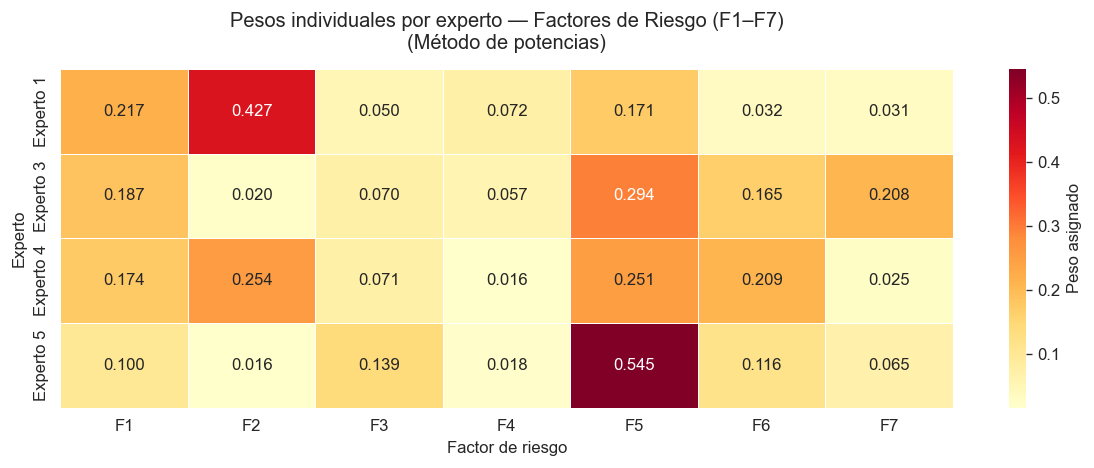

Gráfica guardada: heatmap_pesos_riesgo.png


In [11]:
# ═══════════════════════════════════════════════════════════════════
# Gráfica 1: Heatmap de pesos individuales — Factores de Riesgo
# ═══════════════════════════════════════════════════════════════════
# El heatmap muestra la matriz de pesos donde cada fila es un experto
# y cada columna es un factor. Los colores más intensos indican mayor
# peso asignado. Permite detectar visualmente si hay consenso entre
# los expertos o si alguno tiene una percepción muy diferente.

if agregacion_riesgo is not None:
    W = agregacion_riesgo['W_individuales']
    aptos = agregacion_riesgo['aptos']

    nombres_expertos = [r['nombre'].split('—')[0].strip() for r in aptos]

    fig, ax = plt.subplots(figsize=(10, 4))
    sns.heatmap(
        W,
        annot=True, fmt='.3f',
        xticklabels=ETIQUETAS_RIESGO,
        yticklabels=nombres_expertos,
        cmap='YlOrRd',
        linewidths=0.5,
        ax=ax,
        cbar_kws={'label': 'Peso asignado'}
    )
    ax.set_title(
        'Pesos individuales por experto — Factores de Riesgo (F1–F7)\n'
        '(Método de potencias)',
        fontsize=12, pad=12
    )
    ax.set_xlabel('Factor de riesgo', fontsize=10)
    ax.set_ylabel('Experto', fontsize=10)
    plt.tight_layout()
    plt.savefig('heatmap_pesos_riesgo.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Gráfica guardada: heatmap_pesos_riesgo.png')

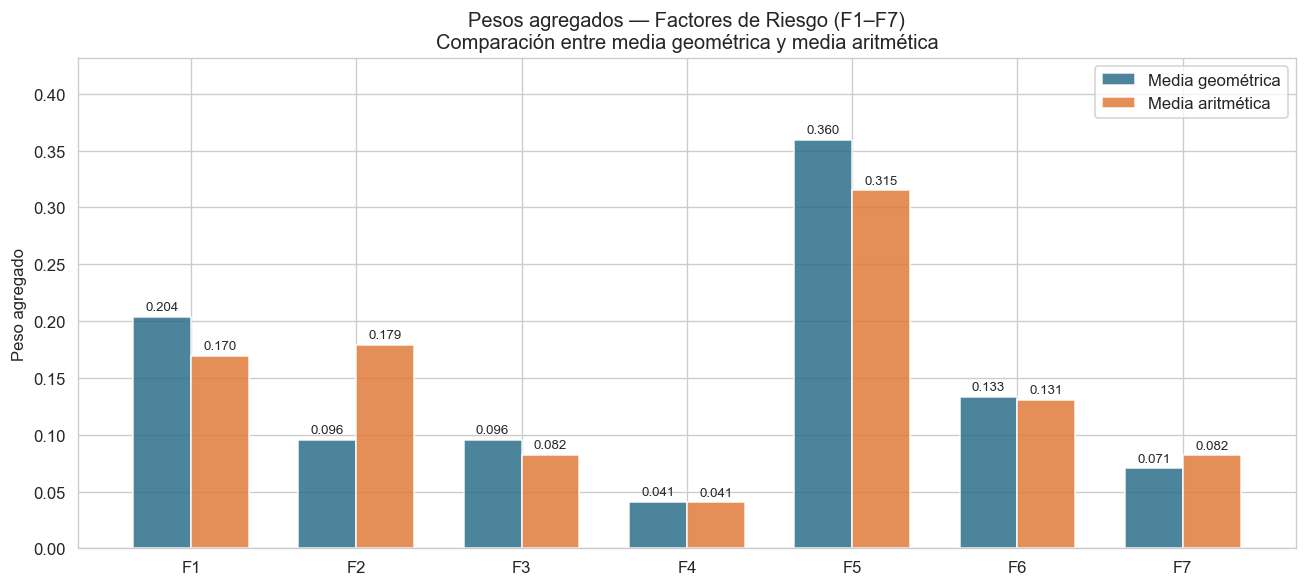

Gráfica guardada: barras_pesos_riesgo.png


In [12]:
# ═══════════════════════════════════════════════════════════════════
# Gráfica 2: Barras comparativas de pesos agregados — Riesgo
# ═══════════════════════════════════════════════════════════════════
# Se muestran en barras agrupadas los pesos obtenidos por media
# geométrica y aritmética para cada factor de riesgo. La cercanía
# entre ambas barras indica robustez del resultado ante el método
# de agregación elegido.

if agregacion_riesgo is not None:
    w_geom = agregacion_riesgo['w_geom']
    w_arit = agregacion_riesgo['w_arit']
    etiq   = ETIQUETAS_RIESGO

    x = np.arange(len(etiq))
    ancho = 0.35

    fig, ax = plt.subplots(figsize=(11, 5))
    barras1 = ax.bar(x - ancho/2, w_geom, ancho,
                     label='Media geométrica', color='#2C6E8A', alpha=0.85)
    barras2 = ax.bar(x + ancho/2, w_arit, ancho,
                     label='Media aritmética', color='#E07B39', alpha=0.85)

    # Etiquetas sobre las barras
    for b in barras1:
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.003,
                f'{b.get_height():.3f}', ha='center', va='bottom', fontsize=8)
    for b in barras2:
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.003,
                f'{b.get_height():.3f}', ha='center', va='bottom', fontsize=8)

    ax.set_xticks(x)
    ax.set_xticklabels(etiq, fontsize=10)
    ax.set_ylabel('Peso agregado', fontsize=10)
    ax.set_title(
        'Pesos agregados — Factores de Riesgo (F1–F7)\n'
        'Comparación entre media geométrica y media aritmética',
        fontsize=12
    )
    ax.legend(fontsize=10)
    ax.set_ylim(0, max(w_geom.max(), w_arit.max()) * 1.2)
    plt.tight_layout()
    plt.savefig('barras_pesos_riesgo.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Gráfica guardada: barras_pesos_riesgo.png')

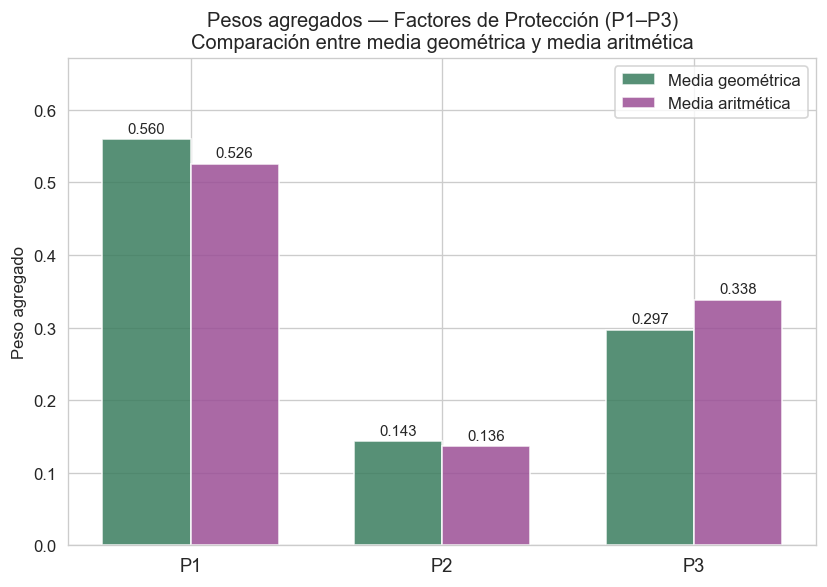

Gráfica guardada: barras_pesos_proteccion.png


In [13]:
# ═══════════════════════════════════════════════════════════════════
# Gráfica 3: Barras comparativas de pesos agregados — Protección
# ═══════════════════════════════════════════════════════════════════

if agregacion_prot is not None:
    w_geom_p = agregacion_prot['w_geom']
    w_arit_p = agregacion_prot['w_arit']
    etiq_p   = ETIQUETAS_PROTECCION

    x = np.arange(len(etiq_p))
    ancho = 0.35

    fig, ax = plt.subplots(figsize=(7, 5))
    barras1 = ax.bar(x - ancho/2, w_geom_p, ancho,
                     label='Media geométrica', color='#3A7D5E', alpha=0.85)
    barras2 = ax.bar(x + ancho/2, w_arit_p, ancho,
                     label='Media aritmética', color='#9B4F96', alpha=0.85)

    for b in barras1:
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.005,
                f'{b.get_height():.3f}', ha='center', va='bottom', fontsize=9)
    for b in barras2:
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.005,
                f'{b.get_height():.3f}', ha='center', va='bottom', fontsize=9)

    ax.set_xticks(x)
    ax.set_xticklabels(etiq_p, fontsize=11)
    ax.set_ylabel('Peso agregado', fontsize=10)
    ax.set_title(
        'Pesos agregados — Factores de Protección (P1–P3)\n'
        'Comparación entre media geométrica y media aritmética',
        fontsize=12
    )
    ax.legend(fontsize=10)
    ax.set_ylim(0, max(w_geom_p.max(), w_arit_p.max()) * 1.2)
    plt.tight_layout()
    plt.savefig('barras_pesos_proteccion.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Gráfica guardada: barras_pesos_proteccion.png')

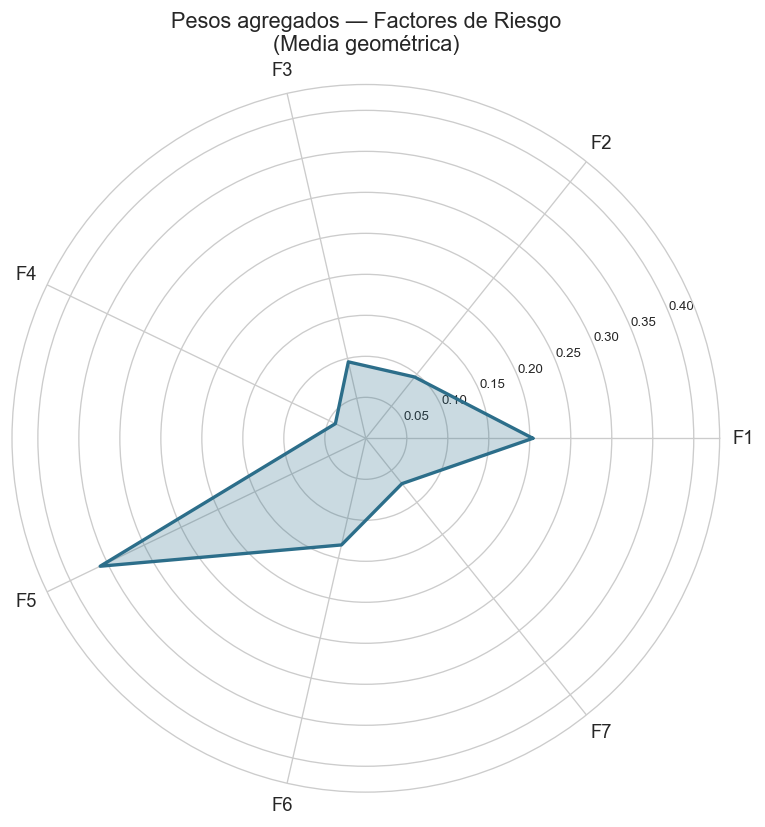

Gráfica guardada: radar_pesos_riesgo.png


In [14]:
# ═══════════════════════════════════════════════════════════════════
# Gráfica 4: Gráfica de radar — Pesos de Riesgo (media geométrica)
# ═══════════════════════════════════════════════════════════════════
# La gráfica de radar (spider chart) es útil para comunicar los pesos
# de los siete factores de manera visual en presentaciones. Cada eje
# corresponde a un factor y la distancia al centro indica el peso.

if agregacion_riesgo is not None:
    pesos = agregacion_riesgo['w_geom']
    etiq  = ETIQUETAS_RIESGO
    N     = len(etiq)

    # Ángulos del radar: uno por factor, más el cierre del polígono
    angulos = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
    angulos += angulos[:1]  # cerrar el polígono

    pesos_radar = pesos.tolist()
    pesos_radar += pesos_radar[:1]  # cerrar

    fig, ax = plt.subplots(figsize=(7, 7), subplot_kw={'polar': True})

    ax.plot(angulos, pesos_radar, color='#2C6E8A', linewidth=2)
    ax.fill(angulos, pesos_radar, color='#2C6E8A', alpha=0.25)

    ax.set_xticks(angulos[:-1])
    ax.set_xticklabels(etiq, fontsize=11)
    ax.set_ylim(0, max(pesos) * 1.2)
    ax.set_title(
        'Pesos agregados — Factores de Riesgo\n(Media geométrica)',
        fontsize=13, pad=20
    )
    ax.yaxis.set_tick_params(labelsize=8)

    plt.tight_layout()
    plt.savefig('radar_pesos_riesgo.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Gráfica guardada: radar_pesos_riesgo.png')

---
## Sección 11: Resumen final de resultados

Esta sección consolida los vectores de pesos agregados finales —los insumos directos para el índice de probabilidad propuesto en el Capítulo 5— en tablas limpias y exportables. Se presentan los pesos por ambos métodos de agregación para que en el texto de la tesina puedas argumentar cuál elegir (la recomendación metodológica es la **media geométrica**).

Los vectores se exportan también a CSV para que puedan integrarse directamente en los cálculos del Capítulo 5 sin necesidad de volver a correr el notebook.

In [15]:
print('=' * 65)
print('  RESUMEN FINAL — VECTORES DE PESOS AHP')
print('=' * 65)

# ── Factores de Riesgo ───────────────────────────────────────────
if agregacion_riesgo is not None:
    print('\n  FACTORES DE RIESGO (F1–F7):')
    df_final_r = pd.DataFrame({
        'Factor': ETIQUETAS_RIESGO,
        'Descripción': [f.split(': ')[1] for f in FACTORES_RIESGO],
        'Peso (Med. Geométrica)': np.round(agregacion_riesgo['w_geom'], 5),
        'Peso (Med. Aritmética)': np.round(agregacion_riesgo['w_arit'], 5),
    })
    print(df_final_r.to_string(index=False))
    print(f'\n  Suma (Geométrica): {agregacion_riesgo["w_geom"].sum():.6f}')
    print(f'  Suma (Aritmética): {agregacion_riesgo["w_arit"].sum():.6f}')
    df_final_r.to_csv('pesos_factores_riesgo.csv', index=False)
    print('  → Exportado a: pesos_factores_riesgo.csv')

# ── Factores de Protección ───────────────────────────────────────
if agregacion_prot is not None:
    print('\n  FACTORES DE PROTECCIÓN (P1–P3):')
    df_final_p = pd.DataFrame({
        'Factor': ETIQUETAS_PROTECCION,
        'Descripción': [f.split(': ')[1] for f in FACTORES_PROTECCION],
        'Peso (Med. Geométrica)': np.round(agregacion_prot['w_geom'], 5),
        'Peso (Med. Aritmética)': np.round(agregacion_prot['w_arit'], 5),
    })
    print(df_final_p.to_string(index=False))
    print(f'\n  Suma (Geométrica): {agregacion_prot["w_geom"].sum():.6f}')
    print(f'  Suma (Aritmética): {agregacion_prot["w_arit"].sum():.6f}')
    df_final_p.to_csv('pesos_factores_proteccion.csv', index=False)
    print('  → Exportado a: pesos_factores_proteccion.csv')

print('\n' + '=' * 65)
print('  Análisis AHP completo.')
print('=' * 65)

  RESUMEN FINAL — VECTORES DE PESOS AHP

  FACTORES DE RIESGO (F1–F7):
Factor                       Descripción  Peso (Med. Geométrica)  Peso (Med. Aritmética)
    F1           Violencia en el entorno                 0.20381                 0.16963
    F2    Precariedad económica familiar                 0.09560                 0.17923
    F3                 Deserción escolar                 0.09567                 0.08248
    F4   Identificación con narcocultura                 0.04117                 0.04063
    F5   Proximidad al crimen organizado                 0.35962                 0.31512
    F6                 Uso de sustancias                 0.13340                 0.13085
    F7 Ausencia de pertenencia prosocial                 0.07074                 0.08206

  Suma (Geométrica): 1.000000
  Suma (Aritmética): 1.000000
  → Exportado a: pesos_factores_riesgo.csv

  FACTORES DE PROTECCIÓN (P1–P3):
Factor                             Descripción  Peso (Med. Geométrica)  Peso (

---
## Sección 12: Notas metodológicas

### ¿Por qué usar la media geométrica para agregar?
En el AHP grupal, la media geométrica de los **juicios** individuales (método AIJ, *Aggregation of Individual Judgments*) es la única forma de agregación que preserva la propiedad de reciprocidad en la escala de Saaty. Si bien aquí se aplica la media geométrica sobre los **pesos** ya derivados (no sobre las entradas de la matriz), el razonamiento sigue siendo válido: los pesos AHP son intrínsecamente multiplicativos (representan razones), por lo que la media geométrica es más apropiada que la aritmética para combinarlos. La diferencia entre ambas es numéricamente pequeña cuando los expertos tienen percepciones similares, pero la media geométrica es la recomendación estándar en la literatura.

### Interpretación del RC
Un RC < 0.37 no garantiza que los juicios sean 'correctos' en sentido sustantivo; únicamente indica que son internamente coherentes. Es perfectamente posible tener una matriz perfectamente consistente cuyos valores reflejen un juicio experto equivocado. La consistencia es una condición necesaria pero no suficiente para la validez del vector de pesos.

### Limitaciones del método AHP
Como se señala en la Sección 3.7 de la tesina:
- Los pesos derivados dependen del grupo de expertos consultado y no son generalizables fuera de ese contexto.
- La escala de Saaty (1–9) impone límites en la expresión de diferencias extremas de importancia.
- El número de comparaciones crece cuadráticamente con n, lo que aumenta la carga cognitiva del experto y la probabilidad de inconsistencias en matrices grandes.
- El método no incorpora incertidumbre en los juicios; una extensión futura podría usar AHP difuso (*fuzzy AHP*) para modelar esa incertidumbre de manera explícita.